In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score

from sklearn.tree import DecisionTreeClassifier

from sklearn.tree import plot_tree

from sklearn.ensemble import RandomForestClassifier

In [7]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [8]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
df.TotalCharges = pd.to_numeric(df.TotalCharges, errors = 'coerce')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [12]:
df.dropna(how = 'any', inplace = True)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [14]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [15]:
df.Churn.value_counts()/len(df)*100

Churn
No     73.421502
Yes    26.578498
Name: count, dtype: float64

In [16]:
X = df.drop(["customerID","Churn"],axis = 1)

In [17]:
Y = df.Churn.values

In [18]:
X.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'],
      dtype='object')

In [19]:
Y

array(['No', 'No', 'Yes', ..., 'No', 'Yes', 'No'],
      shape=(7032,), dtype=object)

# Convert categorical features to numericals --> Feature Encoding --> Dummy Encoding


In [20]:
X = pd.get_dummies(X, columns = ['gender','Partner','Dependents','PhoneService','MultipleLines','InternetService','OnlineSecurity',
                                'OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaperlessBilling',
                                'PaymentMethod',], drop_first = True, dtype = 'int')

In [21]:
X.head(1)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


# Splitting the data into training & test


In [22]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2)

In [23]:
len(X_train)

5625

In [24]:
len(Y_train)

5625

In [25]:
len(X_test)

1407

In [26]:
len(Y_test)

1407

# Feature Scaling


In [27]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [28]:
X_train

array([[-0.44477853,  0.18311854, -0.32715235, ..., -0.52130725,
        -0.70937074,  1.829477  ],
       [-0.44477853,  1.60459409,  1.4325373 , ...,  1.91825454,
        -0.70937074, -0.5466043 ],
       [-0.44477853,  1.60459409,  0.72036102, ..., -0.52130725,
        -0.70937074, -0.5466043 ],
       ...,
       [-0.44477853,  1.44213974, -1.35806488, ..., -0.52130725,
        -0.70937074, -0.5466043 ],
       [-0.44477853,  0.629868  ,  0.15427218, ..., -0.52130725,
        -0.70937074,  1.829477  ],
       [-0.44477853,  0.50802724, -0.46493937, ..., -0.52130725,
        -0.70937074, -0.5466043 ]], shape=(5625, 30))

In [29]:
X_test

array([[-0.44477853,  1.03600387,  1.31965155, ..., -0.52130725,
         1.4097001 , -0.5466043 ],
       [-0.44477853, -0.26363092, -1.48091114, ..., -0.52130725,
         1.4097001 , -0.5466043 ],
       [ 2.24830997,  1.32029898,  1.47735959, ...,  1.91825454,
        -0.70937074, -0.5466043 ],
       ...,
       [ 2.24830997,  1.32029898, -0.37861497, ..., -0.52130725,
        -0.70937074, -0.5466043 ],
       [-0.44477853, -0.91344831, -1.49917207, ...,  1.91825454,
        -0.70937074, -0.5466043 ],
       [-0.44477853,  0.91416311,  0.3352214 , ...,  1.91825454,
        -0.70937074, -0.5466043 ]], shape=(1407, 30))

# kNN Classifier

In [30]:
knn = KNeighborsClassifier()

knn.fit(X_train, Y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [31]:
y_pred = knn.predict(X_test)

In [32]:
accuracy_score(y_pred, Y_test)*100

76.26154939587776

# New data prediction

In [33]:
data = [[0, 2, 87, 178, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1]]

In [34]:
data = sc.transform(data)

C:\Users\Sameen\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [35]:
predict = knn.predict(data)

In [36]:
predict

array(['Yes'], dtype=object)

In [37]:
probability = knn.predict_proba(data)

In [38]:
probability

array([[0.2, 0.8]])

# Decision Tree Classifier

In [39]:
tree = DecisionTreeClassifier(max_depth = 2)
tree.fit(X_train, Y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [40]:
y_pred_tree = tree.predict(X_test)

In [41]:
accuracy_score(y_pred_tree, Y_test)*100

79.60199004975125

# Tree Visualize

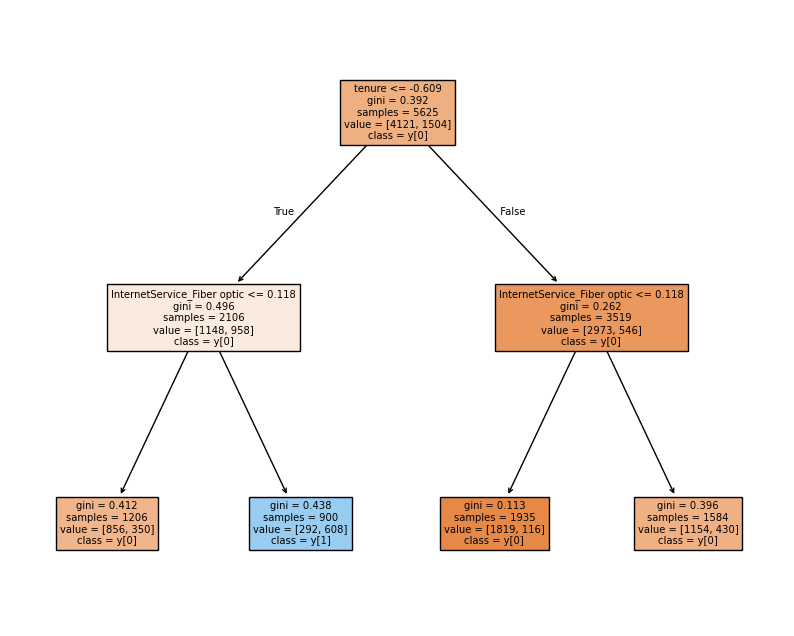

In [42]:
plt.figure(figsize=(10,8))
plot_tree(tree, filled = True, feature_names = X.columns, class_names = True)
plt.show()

# Random Forest Classifier

In [70]:
randomForest = RandomForestClassifier(n_estimators = 60)
randomForest.fit(X_train, Y_train)

,n_estimators,60
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [71]:
y_pred_random = randomForest.predict(X_test)

In [72]:
accuracy_score(y_pred_random, Y_test)*100

80.73916133617625